In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import pickle

data_name = "alpaca"
with open(f"activations_{data_name}.pkl", "rb") as f:
    activations = pickle.load(f)

In [4]:
activations.keys()

dict_keys(['layer_0.input_layernorm', 'layer_0.self_attn_q_proj', 'layer_0.self_attn_k_proj', 'layer_0.self_attn_v_proj', 'layer_0.self_attn_o_proj', 'layer_0.post_attention_layernorm', 'layer_0.mlp_gate_proj', 'layer_0.mlp_act_fn', 'layer_0.mlp_up_proj', 'layer_0.mlp_down_proj', 'layer_1.input_layernorm', 'layer_1.self_attn_q_proj', 'layer_1.self_attn_k_proj', 'layer_1.self_attn_v_proj', 'layer_1.self_attn_o_proj', 'layer_1.post_attention_layernorm', 'layer_1.mlp_gate_proj', 'layer_1.mlp_act_fn', 'layer_1.mlp_up_proj', 'layer_1.mlp_down_proj', 'layer_2.input_layernorm', 'layer_2.self_attn_q_proj', 'layer_2.self_attn_k_proj', 'layer_2.self_attn_v_proj', 'layer_2.self_attn_o_proj', 'layer_2.post_attention_layernorm', 'layer_2.mlp_gate_proj', 'layer_2.mlp_act_fn', 'layer_2.mlp_up_proj', 'layer_2.mlp_down_proj', 'layer_3.input_layernorm', 'layer_3.self_attn_q_proj', 'layer_3.self_attn_k_proj', 'layer_3.self_attn_v_proj', 'layer_3.self_attn_o_proj', 'layer_3.post_attention_layernorm', 'lay

In [14]:
activations['layer_0.self_attn_o_proj']['output'][0].shape

torch.Size([16, 256, 4096])

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tensor = activations['layer_0.self_attn_o_proj']["output"][1].reshape(-1, activations['layer_0.self_attn_o_proj']["output"][0].shape[-1]).to(torch.float32).to(device)
print(tensor.shape)
singular_values = torch.linalg.svdvals(tensor)
singular_values

torch.Size([4096, 4096])


tensor([4.9777e+01, 1.2621e+01, 1.1203e+01,  ..., 8.7767e-14, 7.0160e-14,
        7.5011e-15], device='cuda:0')

In [ ]:
def analyze_output_singular_values(layer_name):
    # 一共有32层，把每一层的输出奇异值分布绘制到一张图上，折线图形式
    layer_indices = []
    layer_avg_svs = []
    
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])  # e.g., "layers.0"
        # outputs = activations[layer]["output"]  # list of tensors

        # total_singular_values = 0
        
        # for output in outputs:
        #     tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        #     if not isinstance(tensor, torch.Tensor):
        #         continue
        #     singular_values = torch.linalg.svdvals(tensor)
        #     total_singular_values += singular_values.sum().item()
            
        # avg_singular_value = total_singular_values / len(outputs)
        
        # layer_indices.append(layer_id)
        # layer_avg_svs.append(avg_singular_value)
        
        output = activations[layer]["output"][0]
        tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        # U, S, Vh = torch.linalg.svd(tensor, full_matrices=False)
        singular_values = torch.linalg.svdvals(tensor)
        
        layer_indices.append(layer_id)
        layer_avg_svs.append(singular_values)
        
    return layer_indices, layer_avg_svs


In [44]:
def plot_singular_value_distribution(layer_ids, layer_svs, layer_name):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv.cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-3
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [49]:
def plot_singular_value_topX_distribution(layer_ids, layer_svs, layer_name, X=10):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv[:X].cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name} top {X}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-1
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [25]:
layer_name = "attn_o_proj"
layer_ids, layer_svs = analyze_output_singular_values(layer_name)

/tmp/ipykernel_1880649/3106386022.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


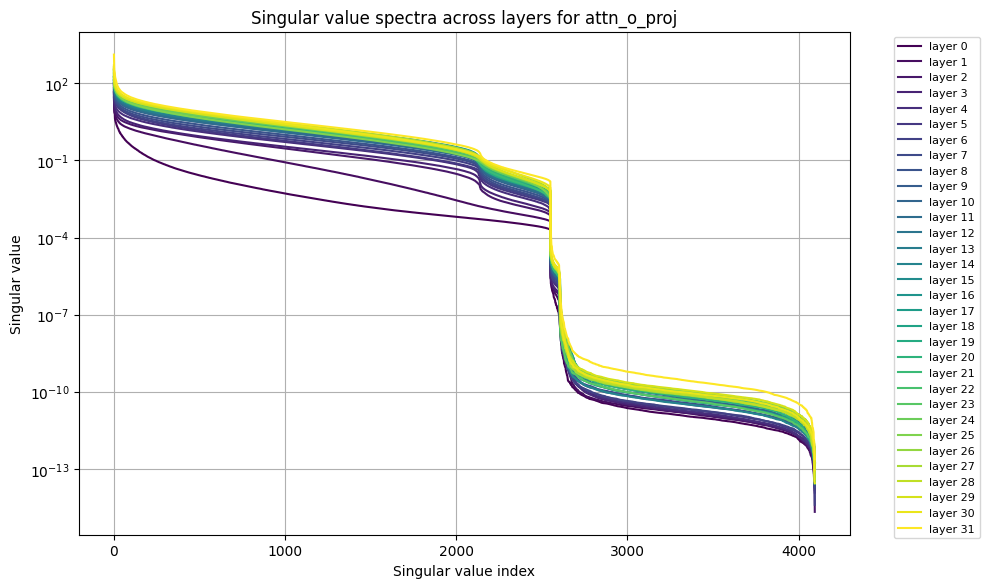

In [46]:
plot_singular_value_distribution(layer_ids, layer_svs, 'attn_o_proj')

/tmp/ipykernel_1880649/3210539342.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


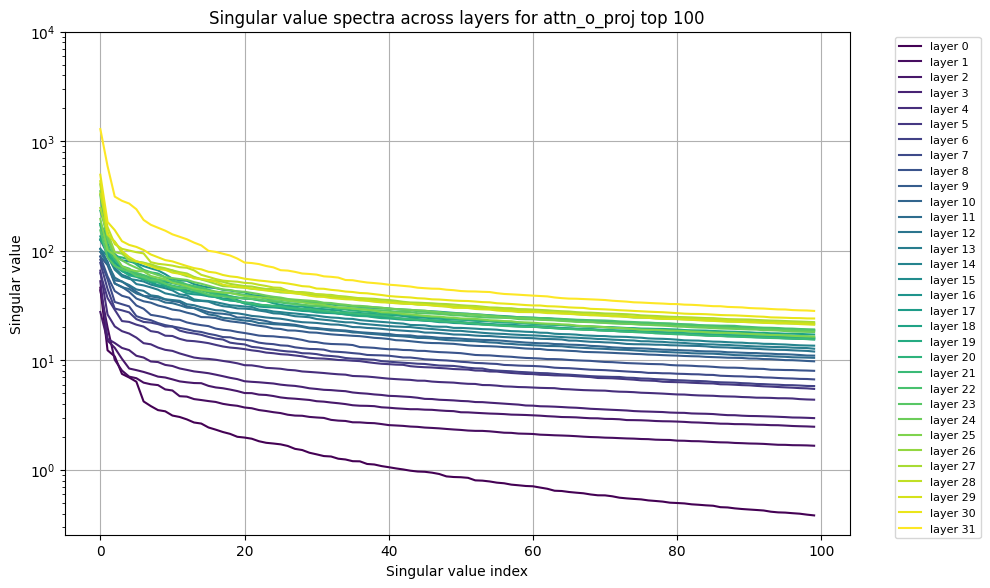

In [50]:
plot_singular_value_topX_distribution(layer_ids, layer_svs, 'attn_o_proj', X=100)

A = L1 @ L2 + R

探讨一下R的数值分布规律

In [52]:
from meft.linalg.qb import randomized_qb

In [90]:
tensor = activations['layer_31.self_attn_o_proj']["output"][1].reshape(-1, activations['layer_31.self_attn_o_proj']["output"][0].shape[-1]).to(torch.float32).to(device)
print(tensor.shape)

Q, B = randomized_qb(tensor, rank=128)

torch.Size([4096, 4096])


In [91]:
Q.shape, B.shape

(torch.Size([4096, 128]), torch.Size([128, 4096]))

In [92]:
R = tensor - Q @ B
R.shape
R

tensor([[ 2.4970e-04,  2.9306e-04,  2.8341e-04,  ..., -3.3833e-05,
         -2.0097e-06, -8.5430e-05],
        [ 4.6072e-04, -8.3854e-04, -2.2056e-03,  ..., -4.6200e-03,
         -4.6505e-04,  2.1763e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-4.6204e-02, -6.0493e-02, -1.5183e-01,  ...,  9.0014e-02,
         -1.0916e-01, -2.1212e-01],
        [-4.8413e-02, -1.0495e-01, -1.8770e-01,  ...,  1.0973e-01,
         -1.2133e-01, -1.9574e-01],
        [ 1.2001e-01,  1.4406e-01, -1.9689e-01,  ...,  1.3895e-01,
          1.0340e-01, -5.6066e-02]], device='cuda:0')

In [93]:
R.max(), R.min(), R.mean(), R.std()

(tensor(2.3016, device='cuda:0'),
 tensor(-1.4793, device='cuda:0'),
 tensor(-5.3313e-06, device='cuda:0'),
 tensor(0.1007, device='cuda:0'))

In [100]:
torch.sum(R.abs() > 1e-2)

tensor(11264643, device='cuda:0')

R stats: min = -1.4792678 max = 2.3015776 mean = -5.331304e-06


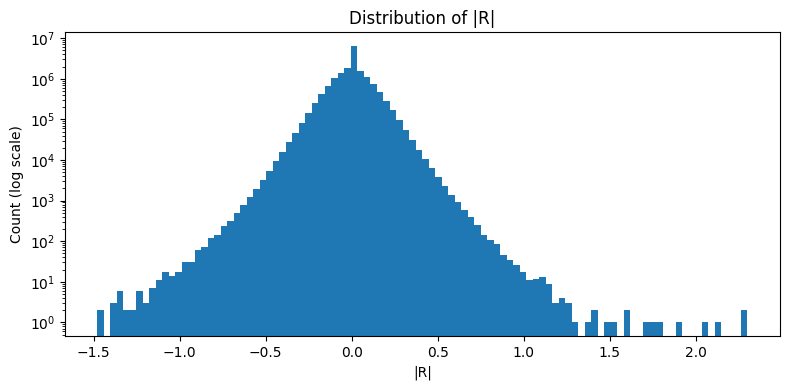

In [99]:
import numpy as np

R_flat = R.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

print("R stats:",
      "min =", R_flat.min(),
      "max =", R_flat.max(),
      "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(R_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|R|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |R|")
plt.tight_layout()
plt.show()

In [ ]:
import bitsandbytes as bnb

quant_state = bnb.functional.quantize_4bit(
    R,
    quant_type="nf4",  # 指定 NF4 格式（适配正态分布的 R）
    blocksize=128,      # 分块量化，平衡精度/速度
    # blocksize=R.shape[-1],  # 不分块
    compress_statistics=True
)

R_nf4_dequant = bnb.functional.dequantize_4bit(*quant_state)

mse = torch.mean((R - R_nf4_dequant)**2)
print(f"NF4 量化 MSE: {mse.item()}")

NF4 量化 MSE: 9.689359285403043e-05


In [121]:
R

tensor([[ 2.4970e-04,  2.9306e-04,  2.8341e-04,  ..., -3.3833e-05,
         -2.0097e-06, -8.5430e-05],
        [ 4.6072e-04, -8.3854e-04, -2.2056e-03,  ..., -4.6200e-03,
         -4.6505e-04,  2.1763e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-4.6204e-02, -6.0493e-02, -1.5183e-01,  ...,  9.0014e-02,
         -1.0916e-01, -2.1212e-01],
        [-4.8413e-02, -1.0495e-01, -1.8770e-01,  ...,  1.0973e-01,
         -1.2133e-01, -1.9574e-01],
        [ 1.2001e-01,  1.4406e-01, -1.9689e-01,  ...,  1.3895e-01,
          1.0340e-01, -5.6066e-02]], device='cuda:0')

In [122]:
R_nf4_dequant

tensor([[ 4.1568e-04,  5.7074e-04,  4.1568e-04,  ...,  0.0000e+00,
          0.0000e+00, -1.5378e-04],
        [ 9.4088e-04, -1.0765e-03, -2.1846e-03,  ..., -4.4342e-03,
         -7.6892e-04,  2.0784e-03],
        [-1.6890e-03, -1.6890e-03, -1.6890e-03,  ..., -1.6890e-03,
         -1.6890e-03, -1.6890e-03],
        ...,
        [-3.8637e-02, -7.8408e-02, -1.6758e-01,  ...,  8.0057e-02,
         -9.2525e-02, -2.2646e-01],
        [-4.2395e-02, -8.6035e-02, -1.8388e-01,  ...,  1.1131e-01,
         -1.3009e-01, -1.7297e-01],
        [ 1.2387e-01,  1.6155e-01, -1.9247e-01,  ...,  1.4881e-01,
          1.1410e-01, -6.2392e-02]], device='cuda:0')

In [123]:
type(quant_state)

tuple

In [124]:
len(quant_state[0])

8388608

In [126]:
quant_state[0].dtype

torch.uint8

In [125]:
quant_state[1]